In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import joblib # Para guardar el modelo

# 1. Cargar datos
df = pd.read_csv('../data/consolidado_transformado.csv')
df['fecha_hora'] = pd.to_datetime(df['fecha_hora'])

# 2. Calcular RFM
fecha_actual = df['fecha_hora'].max()
rfm = df.groupby('id_usuario').agg({
    'fecha_hora': lambda x: (fecha_actual - x.max()).days, # Recencia
    'id_transaccion': 'count',                             # Frecuencia
    'precio_final_usd': 'sum'                              # Valor Monetario
}).reset_index()
rfm.columns = ['id_usuario', 'recencia', 'frecuencia', 'valor_monetario']

# Simulamos la tasa de carritos abandonados (si no la tienen real)
np.random.seed(42)
rfm['tasa_abandonos'] = np.random.uniform(0.1, 0.8, size=len(rfm))

# 3. Escalar las variables (Requisito 1)
variables_modelo = ['recencia', 'frecuencia', 'valor_monetario', 'tasa_abandonos']
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[variables_modelo])

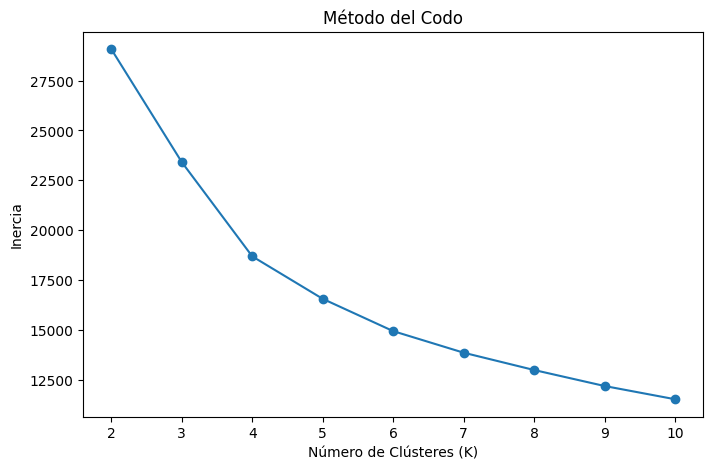

Inercia Final: 18687.18
Índice de Silueta: 0.2587


In [3]:
# 4. Aplicar el método del codo (Requisito 2)
inercia = []
rango_k = range(2, 11) # Empezamos en 2 para poder calcular silueta luego

for k in rango_k:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inercia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(rango_k, inercia, marker='o')
plt.title('Método del Codo')
plt.xlabel('Número de Clústeres (K)')
plt.ylabel('Inercia')
plt.show()

# --- ASUMIENDO QUE EL CODO ESTÁ EN K=4 (Debes verificarlo visualmente) ---
k_optimo = 4 

# 5. Entrenar K-Means con K óptimo (Requisito 3)
modelo_kmeans = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
rfm['cluster'] = modelo_kmeans.fit_predict(rfm_scaled)

# 6. Reportar Métricas (Requisito 7)
inercia_final = modelo_kmeans.inertia_
silueta = silhouette_score(rfm_scaled, rfm['cluster'])
print(f"Inercia Final: {inercia_final:.2f}")
print(f"Índice de Silueta: {silueta:.4f}")

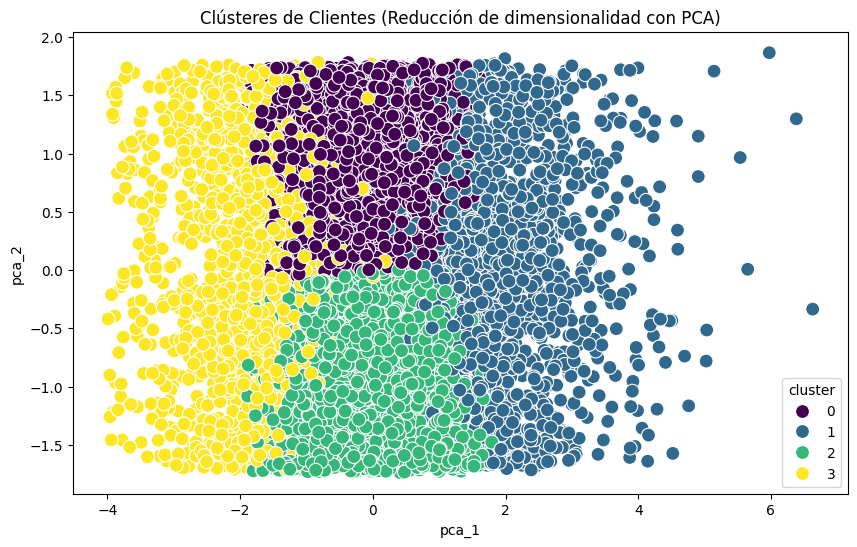

Modelo, scaler y resultados guardados correctamente.


In [4]:
# 7. Visualizar con PCA (Requisito 5)
pca = PCA(n_components=2)
rfm_pca = pca.fit_transform(rfm_scaled)
rfm['pca_1'] = rfm_pca[:, 0]
rfm['pca_2'] = rfm_pca[:, 1]

plt.figure(figsize=(10, 6))
sns.scatterplot(data=rfm, x='pca_1', y='pca_2', hue='cluster', palette='viridis', s=100)
plt.title('Clústeres de Clientes (Reducción de dimensionalidad con PCA)')
plt.show()

# 8. Guardar el modelo y los resultados (Requisito 6)
# Guardamos el modelo
joblib.dump(modelo_kmeans, '../models/kmeans_model.pkl')
joblib.dump(scaler, '../models/scaler_kmeans.pkl') # Es vital guardar el scaler también
# Guardamos los resultados en el CSV consolidado o en un nuevo CSV
rfm.to_csv('../data/clientes_segmentados.csv', index=False)
print("Modelo, scaler y resultados guardados correctamente.")

In [5]:
# Calcular el promedio de las variables RFM para cada clúster
resumen_clusteres = rfm.groupby('cluster')[['recencia', 'frecuencia', 'valor_monetario', 'tasa_abandonos']].mean()
print(resumen_clusteres)

           recencia  frecuencia  valor_monetario  tasa_abandonos
cluster                                                         
0         75.962469    4.763027      2305.601086        0.631225
1         65.497188    7.656355      7194.152407        0.454205
2         73.471151    4.942900      2384.314502        0.265762
3        282.731985    2.842604      1660.356675        0.439944


In [6]:
# 1. Definimos el diccionario con los nombres de negocio según nuestro análisis
nombres_segmentos = {
    0: 'Vitrineadores (Alta Fricción)',
    1: 'Clientes VIP (Alto Valor)',
    2: 'Compradores Decididos',
    3: 'Inactivos (Riesgo de Fuga)'
}

# 2. Creamos una nueva columna legible para el Dashboard
rfm['segmento_marketing'] = rfm['cluster'].map(nombres_segmentos)

# 3. Verificamos la distribución final
print(rfm['segmento_marketing'].value_counts())

# 4. Guardamos el dataset final que consumirá el Dashboard de Marketing
rfm.to_csv('../data/clientes_segmentados_final.csv', index=False)
print("Segmentación finalizada y guardada.")

segmento_marketing
Compradores Decididos            3345
Vitrineadores (Alta Fricción)    3224
Clientes VIP (Alto Valor)        1778
Inactivos (Riesgo de Fuga)       1582
Name: count, dtype: int64
Segmentación finalizada y guardada.
